# Amazon Sales Executive Dashboard

## Project Objective

This dashboard summarizes key business metrics and insights derived from Amazon sales data.

### Business Areas Covered

- Sales Performance
- Product Performance
- Fulfillment Analysis
- Customer Segmentation
- Geographical Analysis
- Business Recommendations

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/cleaned_amazon_sales.csv')

df['Date'] = pd.to_datetime(df['Date'])

In [3]:
total_revenue = df['Amount'].sum()

total_orders = df['Order ID'].nunique()

aov = df['Amount'].mean()

cancel_rate = (
    df['Status']
    .str.contains('Cancelled', case=False, na=False)
    .mean()
) * 100

In [4]:
dashboard_kpis = pd.DataFrame({
    'Metric':[
        'Total Revenue',
        'Total Orders',
        'Average Order Value',
        'Cancellation Rate'
    ],
    'Value':[
        round(total_revenue,2),
        total_orders,
        round(aov,2),
        round(cancel_rate,2)
    ]
})

dashboard_kpis

,Metric,Value
0,Total Revenue,78478115.39
1,Total Orders,120201.00
2,Average Order Value,648.64
3,Cancellation Rate,14.21


## Executive Summary

The business generated substantial revenue from over one lakh orders, maintaining a strong fulfillment rate despite a cancellation rate of approximately 14%.

In [5]:
monthly_sales = (
    df.groupby(
        df['Date'].dt.to_period('M')
    )['Amount']
    .sum()
)

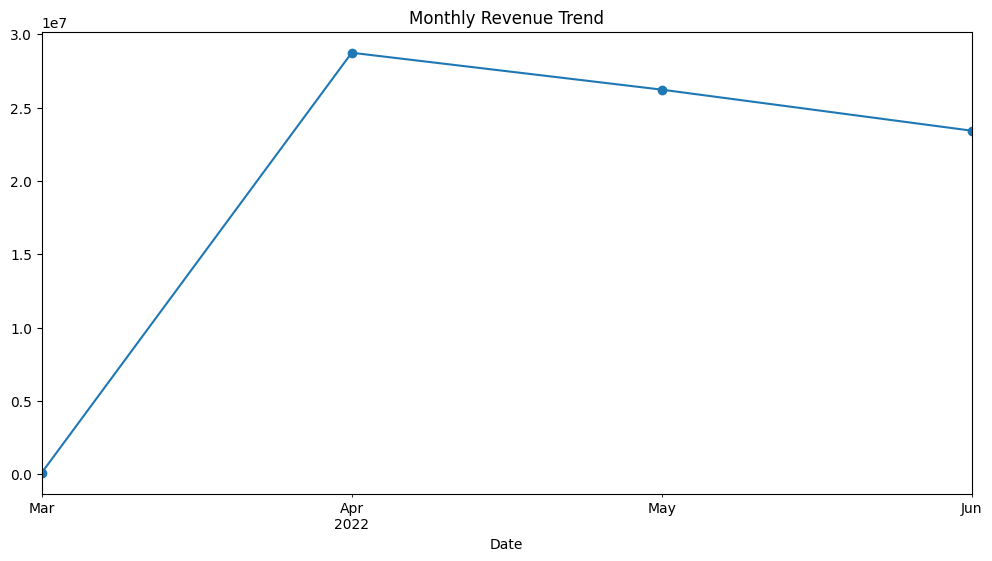

In [6]:
plt.figure(figsize=(12,6))

monthly_sales.plot(marker='o')

plt.title('Monthly Revenue Trend')

plt.show()

In [7]:
top_categories = (
    df.groupby('Category')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

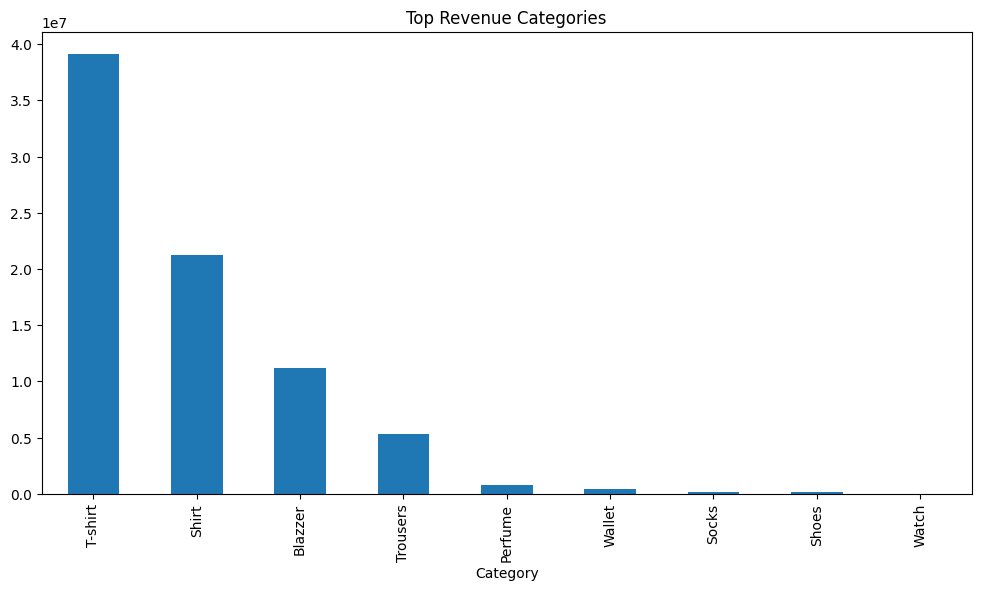

In [8]:
plt.figure(figsize=(12,6))

top_categories.plot(kind='bar')

plt.title('Top Revenue Categories')

plt.show()

In [9]:
top_states = (
    df.groupby('ship-state')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

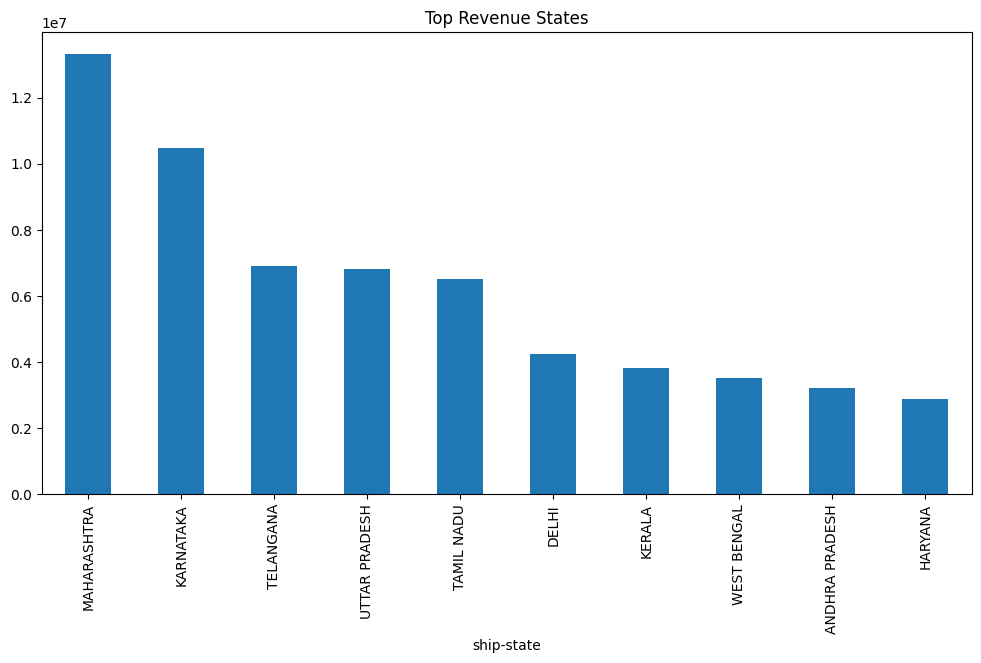

In [10]:
plt.figure(figsize=(12,6))

top_states.plot(kind='bar')

plt.title('Top Revenue States')

plt.show()

In [11]:
segment_revenue = (
    df.groupby('B2B')['Amount']
    .sum()
)

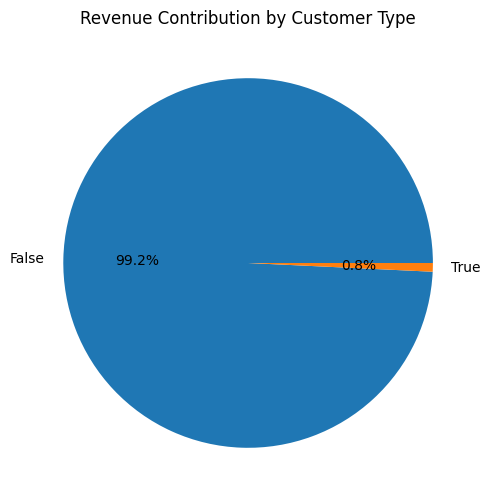

In [12]:
plt.figure(figsize=(8,6))

segment_revenue.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')

plt.title(
    'Revenue Contribution by Customer Type'
)

plt.show()

In [13]:
fulfillment = (
    df['Fulfilment']
    .value_counts()
)

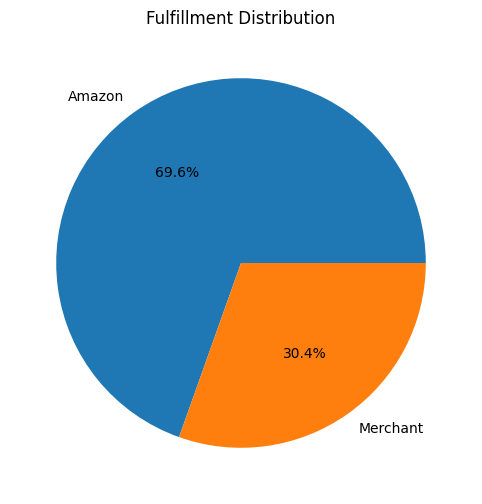

In [14]:
plt.figure(figsize=(8,6))

fulfillment.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')

plt.title(
    'Fulfillment Distribution'
)

plt.show()

# Top Strategic Insights

1. T-shirt category generated the highest revenue and order volume.

2. Maharashtra emerged as the highest revenue-generating state.

3. Approximately 14% of orders were cancelled, representing a major optimization opportunity.

4. Revenue peaked in April 2022 before declining in later months.

5. The business is primarily driven by B2C customers.

# Business Recommendations

1. Prioritize inventory for top-performing categories.

2. Increase marketing efforts in high-revenue states.

3. Investigate causes of order cancellations.

4. Strengthen fulfillment processes.

5. Monitor KPIs regularly for performance tracking.

# Conclusion

The analysis reveals strong sales performance, concentrated product demand, and significant regional opportunities. While fulfillment operations perform well overall, reducing cancellations and optimizing inventory planning could further improve profitability and customer satisfaction.